# Customer Loyalty Analysis: Drivers and Customer Segmentation

# Objective:
## Identify the key drivers of customer loyalty (loyalty_points)

### Understand the relationship between:
✔Income
✔Spending behaviour
✔Demographic variables (age, education, product)
✔Build predictive models to estimate loyalty
✔Segment customers into meaningful groups for targeted strategies


# Approach:
The analysis was conducted using the following methods:

## Data analysis:
✔Correlation analysis to identify relationships between variables
✔Exploratory data analysis (EDA) using scatter plots and distributions

## Modelling:
✔Multiple Linear Regression to measure linear relationships
✔Decision Tree Regression to capture non-linear patterns and feature importance

## Segmentation:
### K-Means clustering using:
✔Age
✔Income
✔Spending_score
✔Comparison of k = 5 vs k = 7 clusters to determine optimal segmentation

## Key findings
### Drivers of Loyalty:
✔Spending_score - strongest driver (r = 0.67)
✔Income - second strongest (r = 0.62)

### Weak relationships:
✔Product = weak impact (0.18)
✔Age = no meaningful impact (-0.04)

### Model results:
✔Linear Regression:
R² = 0.827
✔Decision Tree:
R² = 0.882 (better performance)

## Feature importance:
✔Spending behaviour = 51.5%
✔Income = 48.3%

## Segmentation insight:
✔Customers with similar income show very different spending behaviours
✔Behaviour is a stronger factor in differentiating than income
✔There are ~400 Customers sit between segments

# Business interpretation
## Customer loyalty is primarily driven by engagement behaviour and financial capacity, not demographics.
This means:
✔ High engagement coverts to higher loyalty points
✔ Higher income increases ability to engage in gaming/spending
✔ Age and education shows minimal influence
✔ Product - indirect influence 

# Recommendations
### 1. Focus on high-value customers
Target VIP customers (high income + high spending)
Offer loyalty rewards and premium benefits
### 2. Re-engage wealthy low-spenders
Use targeted campaigns to increase engagement
### 3. Leverage behaviour based segmentation
Segment customers using spending behaviour + income
Avoid relying on demographics alone
### 4. Optimise marketing spend
Reduce investment in low-value customers
Focus on high-return segments
### 5. Personalise the strategy
Tailor offers based on spending behaviour patterns
Encourage higher engagement for mid-segment users
### 6. Tracked customers who move between clusters 

# Analysis

In [1]:
# Imports
import numpy as np
import pandas as pd
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm 
from statsmodels.formula.api import ols
from sklearn.linear_model import LinearRegression
from sklearn import linear_model
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn import metrics
import statsmodels.api as sm
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

In [2]:
# load data
data = pd.read_csv(r"C:\Users\lakma\Documents\kaggal_data\turtle_reviews.csv")

data.head(5)

,gender,age,remuneration (k£),spending_score (1-100),loyalty_points,education,language,platform,product,review,summary
0,Male,18,12.30,39,210,graduate,EN,Web,453,"When it comes to a DM's screen, the space on t...",The fact that 50% of this space is wasted on a...
1,Male,23,12.30,81,524,graduate,EN,Web,466,An Open Letter to GaleForce9*:\n\nYour unpaint...,Another worthless Dungeon Master's screen from...
2,Female,22,13.12,6,40,graduate,EN,Web,254,"Nice art, nice printing. Why two panels are f...","pretty, but also pretty useless"
3,Female,25,13.12,77,562,graduate,EN,Web,263,Amazing buy! Bought it as a gift for our new d...,Five Stars
4,Female,33,13.94,40,366,graduate,EN,Web,291,As my review of GF9's previous screens these w...,Money trap


In [3]:
# make a copy
df1 = data.copy()
df1.head(2)

,gender,age,remuneration (k£),spending_score (1-100),loyalty_points,education,language,platform,product,review,summary
0,Male,18,12.3,39,210,graduate,EN,Web,453,"When it comes to a DM's screen, the space on t...",The fact that 50% of this space is wasted on a...
1,Male,23,12.3,81,524,graduate,EN,Web,466,An Open Letter to GaleForce9*:\n\nYour unpaint...,Another worthless Dungeon Master's screen from...


In [4]:
# drop columns
df1.drop(['language', 'platform','review', 'summary'], axis=1, inplace=True)
df1.head(2)

,gender,age,remuneration (k£),spending_score (1-100),loyalty_points,education,product
0,Male,18,12.3,39,210,graduate,453
1,Male,23,12.3,81,524,graduate,466


In [5]:
# clean headers
df1 = df1.rename(columns={ 'remuneration (k£)': 'income',
                            'spending_score (1-100)': 'spending_score'})
df1.head(2)

,gender,age,income,spending_score,loyalty_points,education,product
0,Male,18,12.3,39,210,graduate,453
1,Male,23,12.3,81,524,graduate,466


In [6]:
df1.isnull().sum()

gender            0
age               0
income            0
spending_score    0
loyalty_points    0
education         0
product           0
dtype: int64

In [7]:
df1.describe()

,age,income,spending_score,loyalty_points,product
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,39.495000,48.079060,50.000000,1578.032000,4320.521500
std,13.573212,23.123984,26.094702,1283.239705,3148.938839
min,17.000000,12.300000,1.000000,25.000000,107.000000
25%,29.000000,30.340000,32.000000,772.000000,1589.250000
50%,38.000000,47.150000,50.000000,1276.000000,3624.000000
75%,49.000000,63.960000,73.000000,1751.250000,6654.000000
max,72.000000,112.340000,99.000000,6847.000000,11086.000000


In [8]:
df1.shape

(2000, 7)

# Regression

In [9]:
# correlation between numeric variables
df_numeric = df1[['age', 'income', 'spending_score', 'loyalty_points','product']]
corr_matrix = df_numeric.corr()

print(corr_matrix)

                     age    income  spending_score  loyalty_points   product
age             1.000000 -0.005708       -0.224334       -0.042445  0.003081
income         -0.005708  1.000000        0.005612        0.616065  0.305309
spending_score -0.224334  0.005612        1.000000        0.672310 -0.001649
loyalty_points -0.042445  0.616065        0.672310        1.000000  0.183600
product         0.003081  0.305309       -0.001649        0.183600  1.000000


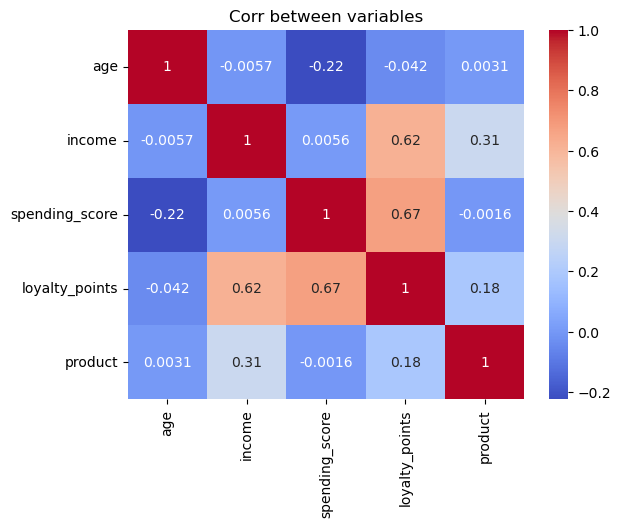

In [10]:
# plot heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Corr between variables')
plt.show()

✔Strongest driver of loyalty points
Spending_score - loyalty_points (0.67)


✔Income is also a strong factor
Income - loyalty_points (0.62)
Higher-income users tend to earn more loyalty points
Monetisation is partly driven by purchasing power

✔Product has weak impact
Product - loyalty_points (0.18)
Product alone does not strongly determine loyalty
However, it may influence user type indirectly (eg: income)

✔Age has almost no effect
Age - loyalty_points (-0.04)
Loyalty behaviour is not age-dependent

✔Spending behaviour is independent of income
Income - spending_score (0.0056 ≈ 0)
Wealth does not directly control engagement

✔Product is mildly linked to income
Product - income (0.30)
Certain products attract higher-income users
Useful for segmentation, not prediction

In [11]:
# relationship between education and loyalty points
df1.groupby('education')['loyalty_points'].mean().sort_values(ascending= False)

education
Basic           2265.040000
graduate        1666.057778
PhD             1499.750000
postgraduate    1499.077500
diploma         1336.021053
Name: loyalty_points, dtype: float64

In [12]:
df1['education'].value_counts()

education
graduate        900
PhD             460
postgraduate    400
diploma         190
Basic            50
Name: count, dtype: int64

In [13]:
# encode education labels
education_order = [['Basic', 'diploma', 'graduate', 'postgraduate', 'PhD']]
encoder = OrdinalEncoder(categories=education_order)

df1['education_encoded'] = encoder.fit_transform(df1[['education']])

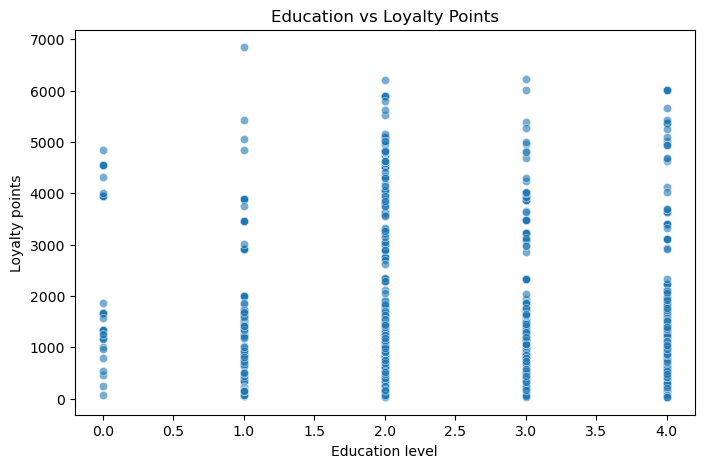

In [14]:
# scatter plot of education after encoding
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='education_encoded',
    y='loyalty_points',
    data=df1,
    alpha=0.6
)

plt.title('Education vs Loyalty Points')
plt.xlabel('Education level')
plt.ylabel('Loyalty points')

plt.show()

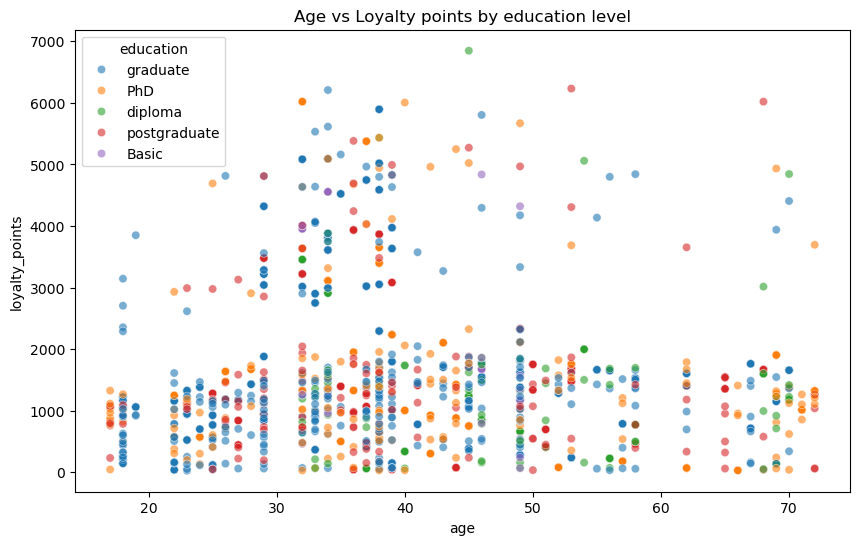

In [15]:
# scatter plot:age
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='age',
    y='loyalty_points',
    hue='education',
    data=df1,
    alpha=0.6
)
plt.title('Age vs Loyalty points by education level')
plt.show()

In [16]:
# relationship between product and loyalty points
df1.groupby('product')['loyalty_points'].mean().sort_values(ascending=False)

product
9080    3340.8
8962    3172.6
4399    3155.6
3403    3072.5
8923    2972.2
         ...  
1307     730.7
231      712.4
2139     689.5
2261     605.3
2173     556.5
Name: loyalty_points, Length: 200, dtype: float64

In [17]:
df1.groupby('age')['loyalty_points'].mean().sort_values(ascending=False)

age
32    2739.518182
34    2711.263636
38    2110.538889
54    2070.300000
29    1972.190909
35    1937.000000
39    1925.562500
37    1820.800000
36    1759.600000
55    1727.600000
33    1698.650000
68    1679.150000
46    1565.200000
53    1543.175000
28    1521.750000
70    1497.200000
49    1475.691667
43    1416.133333
45    1359.200000
50    1329.800000
19    1311.600000
41    1301.833333
72    1263.800000
65    1237.600000
26    1223.125000
69    1208.650000
62    1156.900000
58    1138.375000
56    1125.000000
67    1104.900000
40    1051.350000
44    1045.033333
71    1032.000000
23    1010.600000
42     991.150000
25     958.500000
52     928.400000
17     916.433333
27     893.600000
24     869.500000
18     827.062500
22     719.720000
51     701.900000
57     580.300000
66     350.600000
Name: loyalty_points, dtype: float64

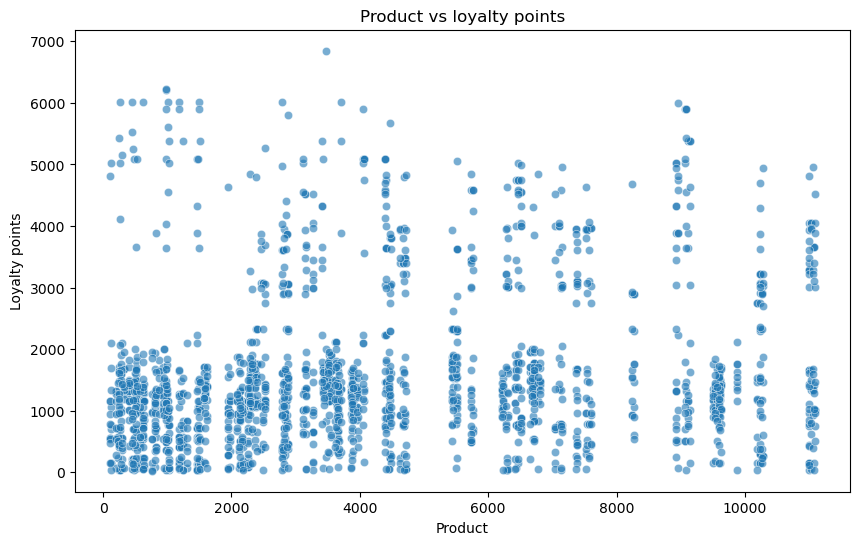

In [18]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    x='product',
    y='loyalty_points',
    data=df1,
    alpha=0.6
)

plt.title('Product vs loyalty points')
plt.xlabel('Product')
plt.ylabel('Loyalty points')
plt.show()

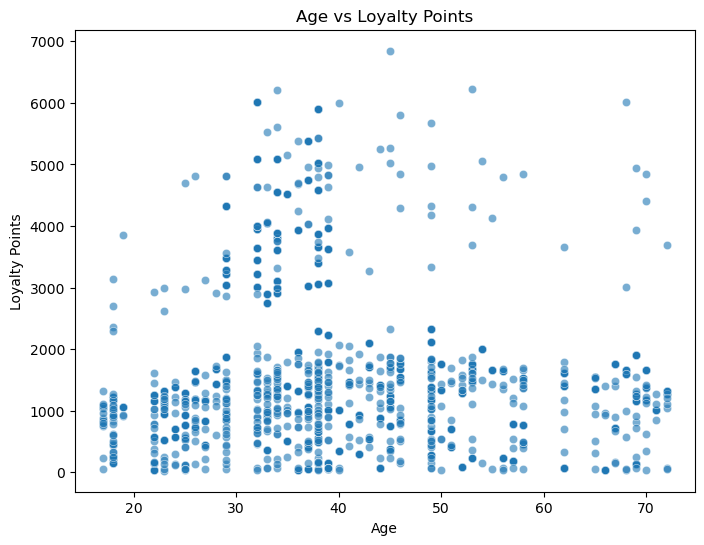

In [19]:
# scatter plot: age vs loyalty points
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='age',
    y='loyalty_points',
    data=df1,
    alpha=0.6
)

plt.title('Age vs Loyalty Points')
plt.xlabel('Age')
plt.ylabel('Loyalty Points')
plt.show()

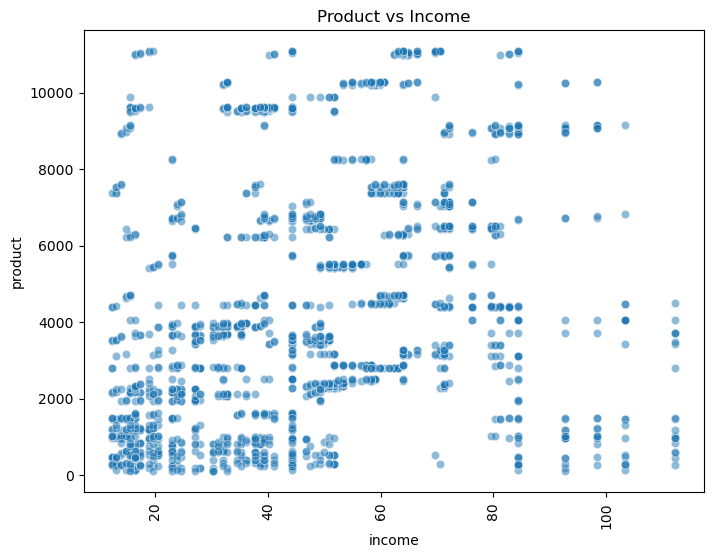

In [20]:
# scatter plot product vs income
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='income',
    y='product',
    data=df1,
    alpha=0.5,
     
)

plt.xticks(rotation=90)
plt.title('Product vs Income')
plt.show()

✔There is no clear linear correlation between higher income earners and the product variable. Instead, the data shows distinct horizontal and vertical clustering. 

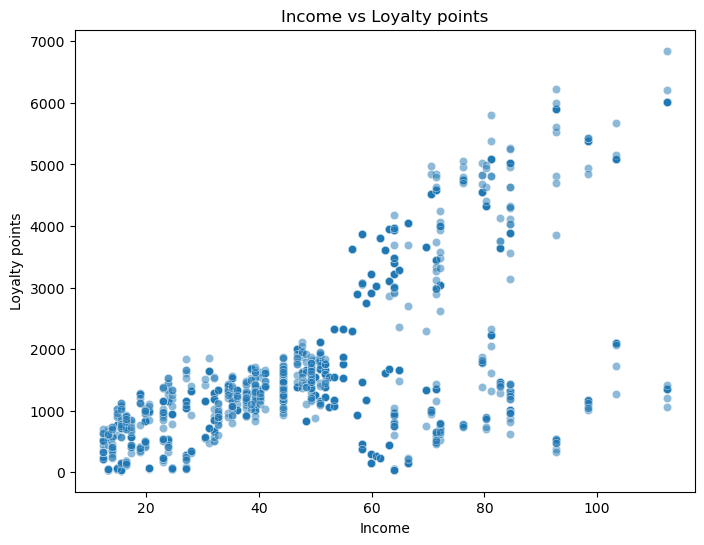

In [21]:
# scatter plot of spending_score vs loyalty point
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df1,
    x='income',
    y='loyalty_points',
    alpha=0.5
)

plt.title('Income vs Loyalty points')
plt.xlabel('Income')
plt.ylabel('Loyalty points')
plt.show()

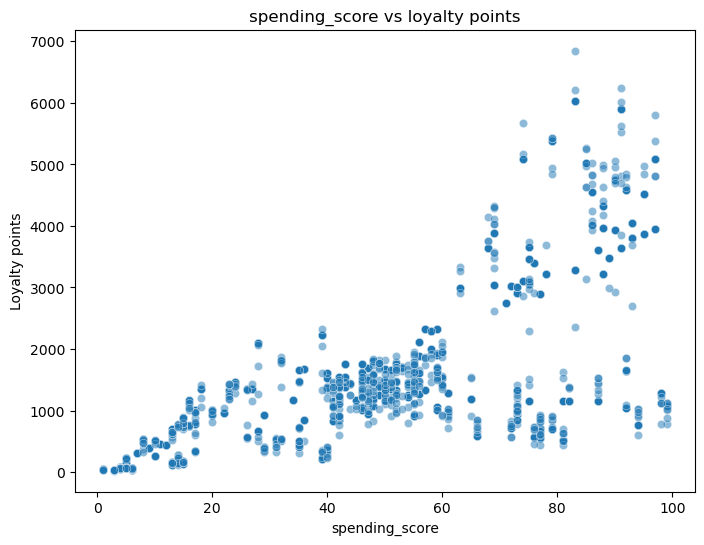

In [22]:
# scatter plot of spending_score vs loyalty_points
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df1,
    x='spending_score',
    y='loyalty_points',
    alpha=0.5
)

plt.title('spending_score vs loyalty points')
plt.xlabel('spending_score')
plt.ylabel('Loyalty points')
plt.show()                

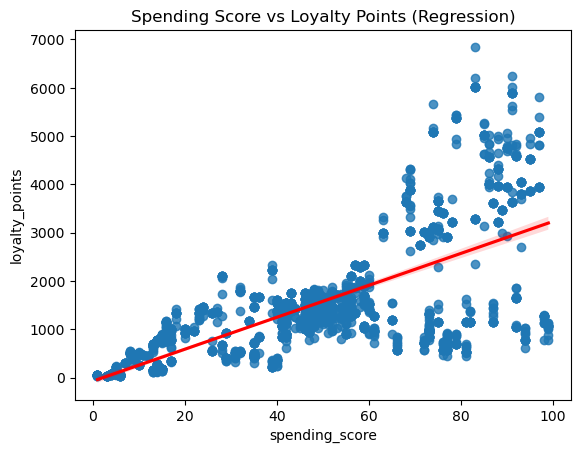

In [23]:
# regression  plot of Spending_score vs loyalty points
sns.regplot(
    x='spending_score',
    y='loyalty_points',
    data=df1,
    line_kws={'color': 'red'}
)

plt.title('Spending Score vs Loyalty Points (Regression)')
plt.show()

## Multiple linear regression model

In [148]:
# Multiple linear Regression of income and , spending_score

# Independent variables (2D)
X = df1[['income', 'spending_score']]

# Dependent variable
y = df1['loyalty_points']

# Model
lm = LinearRegression()
lm.fit(X, y)

LinearRegression()

In [149]:
print("Intercept:", lm.intercept_)
print("Coefficients:", lm.coef_)
print("R² Score:", lm.score(X, y))

Intercept: -1700.3050970144384
Coefficients: [33.97949882 32.89269469]
R² Score: 0.826913470198926


✔ Multiple linear regression is used because the target variable (loyalty points) is influenced by more than one independent factor, income and spending score. 
✔ Income and spending score have very low correlation with each other (0.0056), and therefore no overlapping of information.
✔ This allows the model to estimate the separate contribution of each variable more clearly. 
✔ Multiple regression is therefore better because it captures the combined effect of income and spending behaviour on loyalty points.

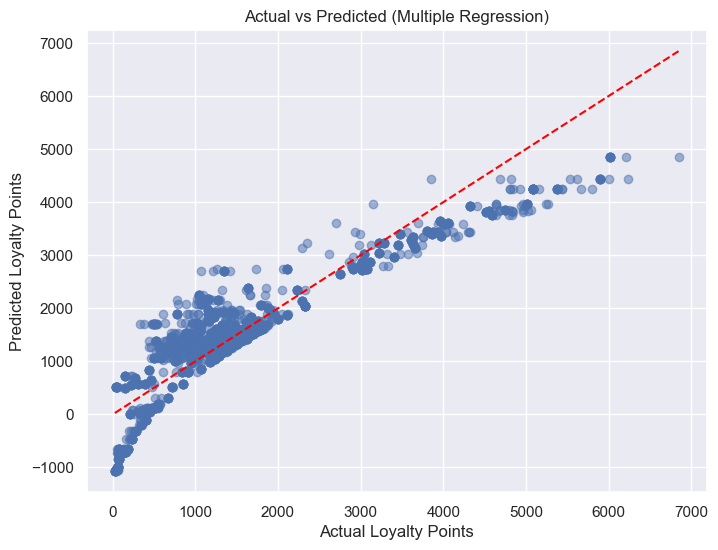

In [217]:
# plot actual and predicted
y_pred = lm.predict(X)

plt.figure(figsize=(8,6))

plt.scatter(y, y_pred, alpha=0.5)

# Perfect line
plt.plot([y.min(), y.max()], [y.min(), y.max()],
         color='red', linestyle='--')

plt.xlabel('Actual Loyalty Points')
plt.ylabel('Predicted Loyalty Points')
plt.title('Actual vs Predicted (Multiple Regression)')

plt.show()

In [152]:
# coefficient of income and spending_score

coeff_df = pd.DataFrame(lm.coef_, X.columns, columns=['Coefficient'])
print(coeff_df)

                Coefficient
income            33.979499
spending_score    32.892695


In [153]:
# print stat summary
import statsmodels.formula.api as ols

f = 'loyalty_points ~ income + spending_score'

model = ols.ols(formula=f, data=df1).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:         loyalty_points   R-squared:                       0.827
Model:                            OLS   Adj. R-squared:                  0.827
Method:                 Least Squares   F-statistic:                     4770.
Date:                Tue, 21 Apr 2026   Prob (F-statistic):               0.00
Time:                        23:30:45   Log-Likelihood:                -15398.
No. Observations:                2000   AIC:                         3.080e+04
Df Residuals:                    1997   BIC:                         3.082e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept      -1700.3051     35.740    -47.

F stat indicate, the model is highly statistically significant.(Prob(F-statistic) = 0.00)
both coeff. are highly significant.
t= 71,845 means that spending score is a stronger predictor than income. 
Intercept = -1700.31 is unrealistic
Skew = 0.103 very close to 0 - symmetric distribution
Kurtosis = 3.115 close to 3 - normal shape

Therefore, Residuals are well-behaved.

✔ loyalty_points = -1700.31 + (33.98 × income) + (32.89 × spending_score)
✔ For every 1 unit increase in spending score, loyalty points increase by ~33 points holding income constant.
✔ For every 1 unit increase in income, loyalty points increase by ~34 points holding spending score constant.
82.6% of variation in loyalty points is explained, very high performing model.
✔ Users with higher income and higher spending behaviour accumulate significantly more loyalty points.

### Diagnostics for multiple linear regression

In [ ]:
### Linearity:
The relationship between each independent variable and the dependent variable should be approximately linear.

✔ Independence of predictors:
Independent variables should not be highly correlated.
    
✔ Homoscedasticity (constant variance):
Residuals should have constant spread across all predicted values.
    
✔ Normality of residuals:
Residuals should be approximately normally distributed.
    
✔ No multicollinearity:
Independent variables should not carry redundant information.
    
✔ Outliers and influence points:
Extreme values should not heavily distort the model.

In [261]:
# checking whether residuals are randomly scattered around 0, Residuals = actual − predicted
# check for check heteroscedasticity

# predictions
y_pred = lm.predict(df1[['income', 'spending_score']])

# residuals
residuals = df1['loyalty_points'] - y_pred

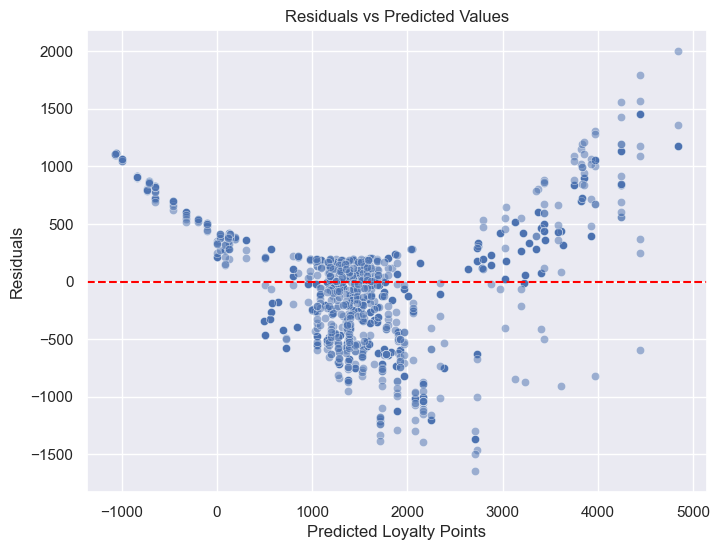

In [262]:
# residuals vs predicted values plot__
plt.figure(figsize=(8,6))

sns.scatterplot(x=y_pred, y=residuals, alpha=0.5)

plt.axhline(y=0, color='red', linestyle='--')

plt.title('Residuals vs Predicted Values')
plt.xlabel('Predicted Loyalty Points')
plt.ylabel('Residuals')

plt.show()

### residuals vs predicted values
✔ There is evidence of non-linearity (clear curved/U-shaped pattern)
✔ There is evidence of heteroscedasticity (variance increases with fitted values)
✔ Residuals are not randomly scattered around zero

<Axes: xlabel='loyalty_points', ylabel='Count'>

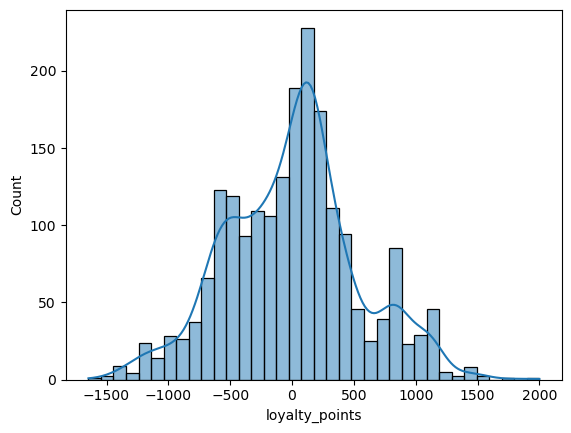

In [157]:
# distribution of residuals
sns.histplot(residuals, kde=True)

✔ The normality assumption of regression is partially satisfied. This indicates that the distribution of loyalty_points is not the problem, but rather the relationship between the variables.

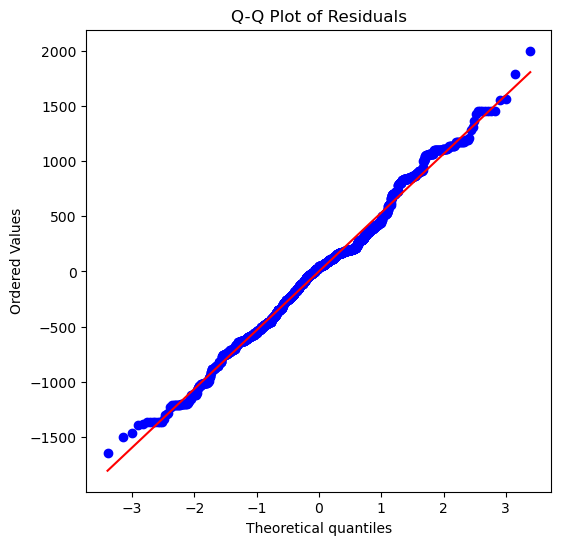

In [158]:
# Q-Q plot: check the distribution of residuals
plt.figure(figsize=(6,6))

stats.probplot(residuals, dist="norm", plot=plt)

plt.title("Q-Q Plot of Residuals")
plt.show()

✔ The residuals are approximately normally distributed and slightly skewed at the tails.

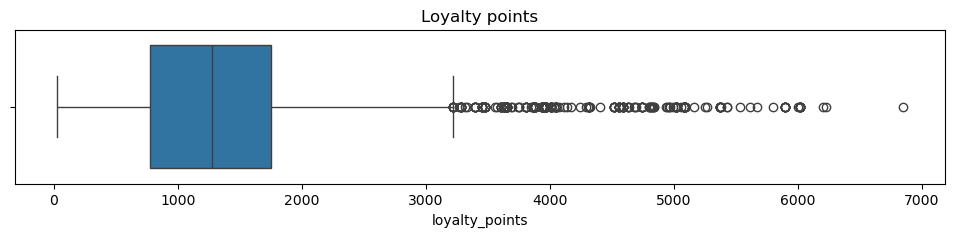

In [160]:
# Check for outliars loyalty

fig, ax = plt.subplots(figsize=(12, 2))
plt.title('Loyalty points')
sns.boxplot(x=df1['loyalty_points'], whis=1.5, ax=ax)
plt.show()

✔ Outliers are present in the loyalty_points variable.

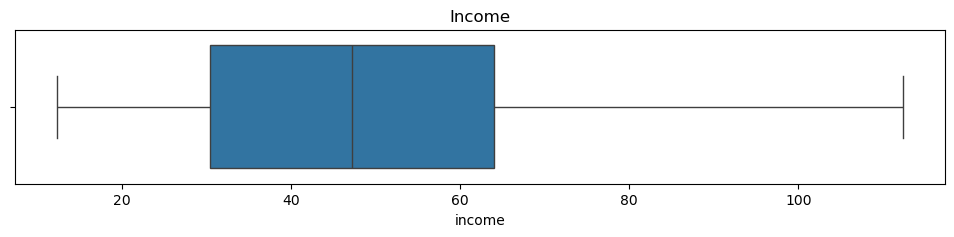

In [161]:
# Check for outliars income

fig, ax = plt.subplots(figsize=(12, 2))
plt.title('Income')
sns.boxplot(x=df1['income'], whis=1.5, ax=ax)

plt.show()

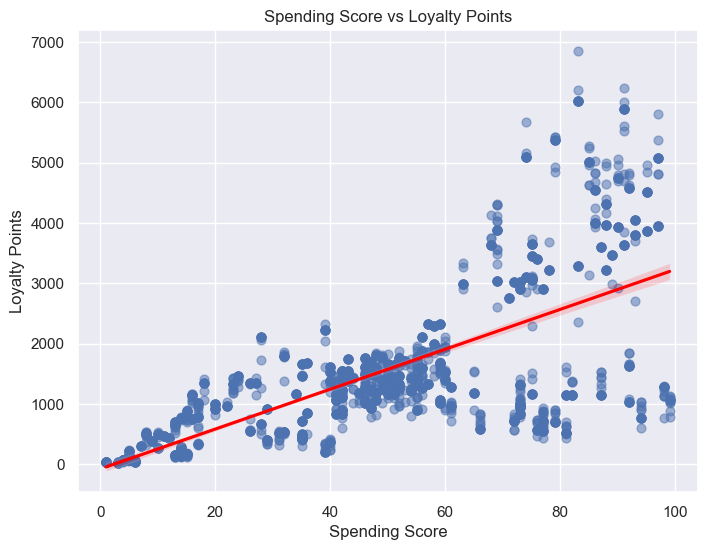

In [263]:
# relationship between predictors and target is linear?
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.regplot(
    data=df1,
    x='spending_score',
    y='loyalty_points',
    scatter_kws={'alpha':0.5, 's':40},
    line_kws={'color':'red'}
)

plt.title('Spending Score vs Loyalty Points')
plt.xlabel('Spending Score')
plt.ylabel('Loyalty Points')

plt.show()

✔ Both income and spending score show an approximately linear relationship with loyalty points. 
✔ Meaning each predictor has a reasonably straight-line relationship with the dependent variable. 

In [ ]:
# Decision tree model

In [163]:
df1.head(5)

,gender,age,income,spending_score,loyalty_points,education,product,education_encoded
0,Male,18,12.30,39,210,graduate,453,2.0
1,Male,23,12.30,81,524,graduate,466,2.0
2,Female,22,13.12,6,40,graduate,254,2.0
3,Female,25,13.12,77,562,graduate,263,2.0
4,Female,33,13.94,40,366,graduate,291,2.0


### Feature engineering for Decision Tree Model

In [24]:
# make a copy of df1
df2 = df1.copy()

In [25]:
# gender encoding
df2['gender'] = df2['gender'].map({'Male': 1, 'Female': 0})

In [26]:
# multiple binary columns for product
df2 = pd.get_dummies(df2, columns=['product'], drop_first=True)

In [27]:
# unique values of age
df2['age'].unique()

array([18, 23, 22, 25, 33, 24, 37, 66, 32, 69, 57, 26, 39, 51, 27, 44, 53,
       29, 43, 38, 62, 52, 17, 49, 40, 67, 46, 35, 58, 45, 50, 71, 72, 65,
       19, 41, 70, 34, 28, 56, 54, 36, 68, 42, 55], dtype=int64)

In [28]:
# age: create bins and labels
bins = [0, 20, 30, 40, 50, 60, 100]
labels = ['<20', '20-29', '30-39', '40-49', '50-59', '60+']

df2['age_group'] = pd.cut(df2['age'], bins=bins, labels=labels)

In [29]:
# find unique values
df2['income'].unique()

array([ 12.3 ,  13.12,  13.94,  14.76,  15.58,  16.4 ,  17.22,  18.86,
        19.68,  20.5 ,  22.96,  23.78,  24.6 ,  27.06,  27.88,  30.34,
        31.16,  31.98,  32.8 ,  34.44,  35.26,  36.08,  37.72,  38.54,
        39.36,  40.18,  41.  ,  44.28,  46.74,  47.56,  48.38,  49.2 ,
        50.02,  50.84,  51.66,  52.48,  53.3 ,  54.94,  56.58,  57.4 ,
        58.22,  59.04,  59.86,  60.68,  61.5 ,  62.32,  63.14,  63.96,
        64.78,  66.42,  69.7 ,  70.52,  71.34,  72.16,  76.26,  79.54,
        80.36,  81.18,  82.82,  84.46,  92.66,  98.4 , 103.32, 112.34])

In [30]:
# apply encoder
# define income bins
bins = [0, 20, 40, 60, 80, 100, 120]
labels = ['<20', '20-39', '40-59', '60-79', '80-99', '100+']

# create income groups
df2['income_group'] = pd.cut(df2['income'], bins=bins, labels=labels)

# encode income groups 
le = LabelEncoder()
df2['income_group_encoded'] = le.fit_transform(df2['income_group'])

# check
print(df2[['income', 'income_group', 'income_group_encoded']].head())

   income income_group  income_group_encoded
0   12.30          <20                     5
1   12.30          <20                     5
2   13.12          <20                     5
3   13.12          <20                     5
4   13.94          <20                     5


In [31]:
# check unique values 
df2['spending_score'].unique()

array([39, 81,  6, 77, 40, 76, 94,  3, 72, 14, 99, 15, 13, 79, 35, 66, 29,
       98, 73,  5, 82, 32, 61, 31, 87,  4, 92, 17, 26, 75, 36, 28, 65, 55,
       47, 42, 52, 60, 54, 45, 41, 50, 46, 51, 56, 59, 48, 49, 53, 44, 57,
       58, 43, 91, 95, 11,  9, 34, 71, 88,  7, 10, 93, 12, 97, 74, 22, 90,
       20, 16, 89,  1, 78, 83, 27, 63, 86, 69, 24, 68, 85, 23,  8, 18],
      dtype=int64)

In [32]:
# define spending score bins
bins = [0, 20, 40, 60, 80, 100]
labels = ['Very Low', 'Low', 'Medium', 'High', 'Very High']

# create spending groups
df2['spending_group'] = pd.cut(df2['spending_score'], bins=bins, labels=labels)

# encode spending groups 
le = LabelEncoder()
df2['spending_group_encoded'] = le.fit_transform(df2['spending_group'])

# check
print(df2[['spending_score', 'spending_group', 'spending_group_encoded']].head())

   spending_score spending_group  spending_group_encoded
0              39            Low                       1
1              81      Very High                       3
2               6       Very Low                       4
3              77           High                       0
4              40            Low                       1


In [33]:
df2['education'].unique()

array(['graduate', 'PhD', 'diploma', 'postgraduate', 'Basic'],
      dtype=object)

In [35]:
# education: ordinal encoding
edu_order = [['Basic', 'diploma', 'graduate', 'postgraduate', 'PhD']]

# apply ordinal encoding
encoder = OrdinalEncoder(categories=edu_order)

df2['education_encoded'] = encoder.fit_transform(df2[['education']])

# check
print(df2[['education', 'education_encoded']].head())

  education  education_encoded
0  graduate                2.0
1  graduate                2.0
2  graduate                2.0
3  graduate                2.0
4  graduate                2.0


In [36]:
df2

,gender,age,income,spending_score,loyalty_points,education,education_encoded,product_123,product_195,product_231,...,product_11004,product_11025,product_11056,product_11084,product_11086,age_group,income_group,income_group_encoded,spending_group,spending_group_encoded
0,1,18,12.30,39,210,graduate,2.0,False,False,False,...,False,False,False,False,False,<20,<20,5,Low,1
1,1,23,12.30,81,524,graduate,2.0,False,False,False,...,False,False,False,False,False,20-29,<20,5,Very High,3
2,0,22,13.12,6,40,graduate,2.0,False,False,False,...,False,False,False,False,False,20-29,<20,5,Very Low,4
3,0,25,13.12,77,562,graduate,2.0,False,False,False,...,False,False,False,False,False,20-29,<20,5,High,0
4,0,33,13.94,40,366,graduate,2.0,False,False,False,...,False,False,False,False,False,30-39,<20,5,Low,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,0,37,84.46,69,4031,PhD,4.0,False,False,False,...,False,False,False,False,False,30-39,80-99,4,High,0
1996,0,43,92.66,8,539,PhD,4.0,False,False,False,...,False,False,False,False,False,40-49,80-99,4,Very Low,4
1997,1,34,92.66,91,5614,graduate,2.0,False,False,False,...,False,False,False,False,False,30-39,80-99,4,Very High,3
1998,1,34,98.40,16,1048,PhD,4.0,False,False,False,...,False,False,False,False,False,30-39,80-99,4,Very Low,4


In [37]:
# drop columns that will not use in the modal
df2 = df2.drop(['age', 'income', 'spending_score', 'education','age_group','income_group','spending_group'], axis=1)

In [38]:
df2.head(2)

,gender,loyalty_points,education_encoded,product_123,product_195,product_231,product_249,product_254,product_263,product_283,...,product_10281,product_10995,product_11003,product_11004,product_11025,product_11056,product_11084,product_11086,income_group_encoded,spending_group_encoded
0,1,210,2.0,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,5,1
1,1,524,2.0,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,5,3


In [39]:
df2['education_encoded'].unique()

array([2., 4., 1., 3., 0.])

In [40]:
# covert data type
df2['education_encoded'] = df2['education_encoded'].astype(int)

In [41]:
df2.dtypes

gender                    int64
loyalty_points            int64
education_encoded         int32
product_123                bool
product_195                bool
                          ...  
product_11056              bool
product_11084              bool
product_11086              bool
income_group_encoded      int32
spending_group_encoded    int32
Length: 204, dtype: object

## Decision tree Regressor

In [44]:
# define X and y, remove the target:
X = df2.drop(columns=['loyalty_points'])
y = df2['loyalty_points']

In [45]:
# train decision tree model

from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor(
    max_depth=5,        # controls overfitting
    random_state=42
)

model.fit(X, y)

DecisionTreeRegressor(max_depth=5, random_state=42)

In [46]:
# make predictions
y_pred = model.predict(X)

In [47]:
# evaluate model
from sklearn.metrics import r2_score, mean_squared_error

print("R² Score:", r2_score(y, y_pred))
print("RMSE:", mean_squared_error(y, y_pred, squared=False))

R² Score: 0.88213430573003
RMSE: 440.4462302715241


In [186]:
# visualise feature importance
import pandas as pd

importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values(ascending=False)

spending_group_encoded    0.515288
income_group_encoded      0.482870
education_encoded         0.001689
product_11084             0.000098
product_4491              0.000024
                            ...   
product_2457              0.000000
product_2495              0.000000
product_2518              0.000000
product_2521              0.000000
product_3629              0.000000
Length: 203, dtype: float64

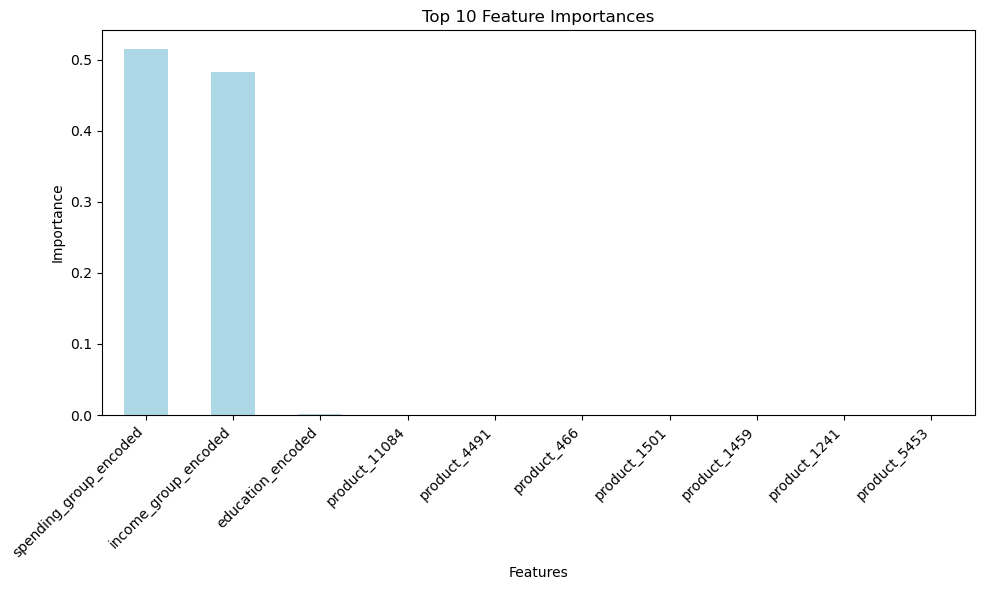

In [52]:
# plot top 10 features of importance
# Take top 10
top10 = importance.head(10)

# Plot
plt.figure(figsize=(10, 6))
top10.plot(kind='bar', color = 'lightblue')
plt.title('Top 10 Feature Importances')
plt.ylabel('Importance')
plt.xlabel('Features')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

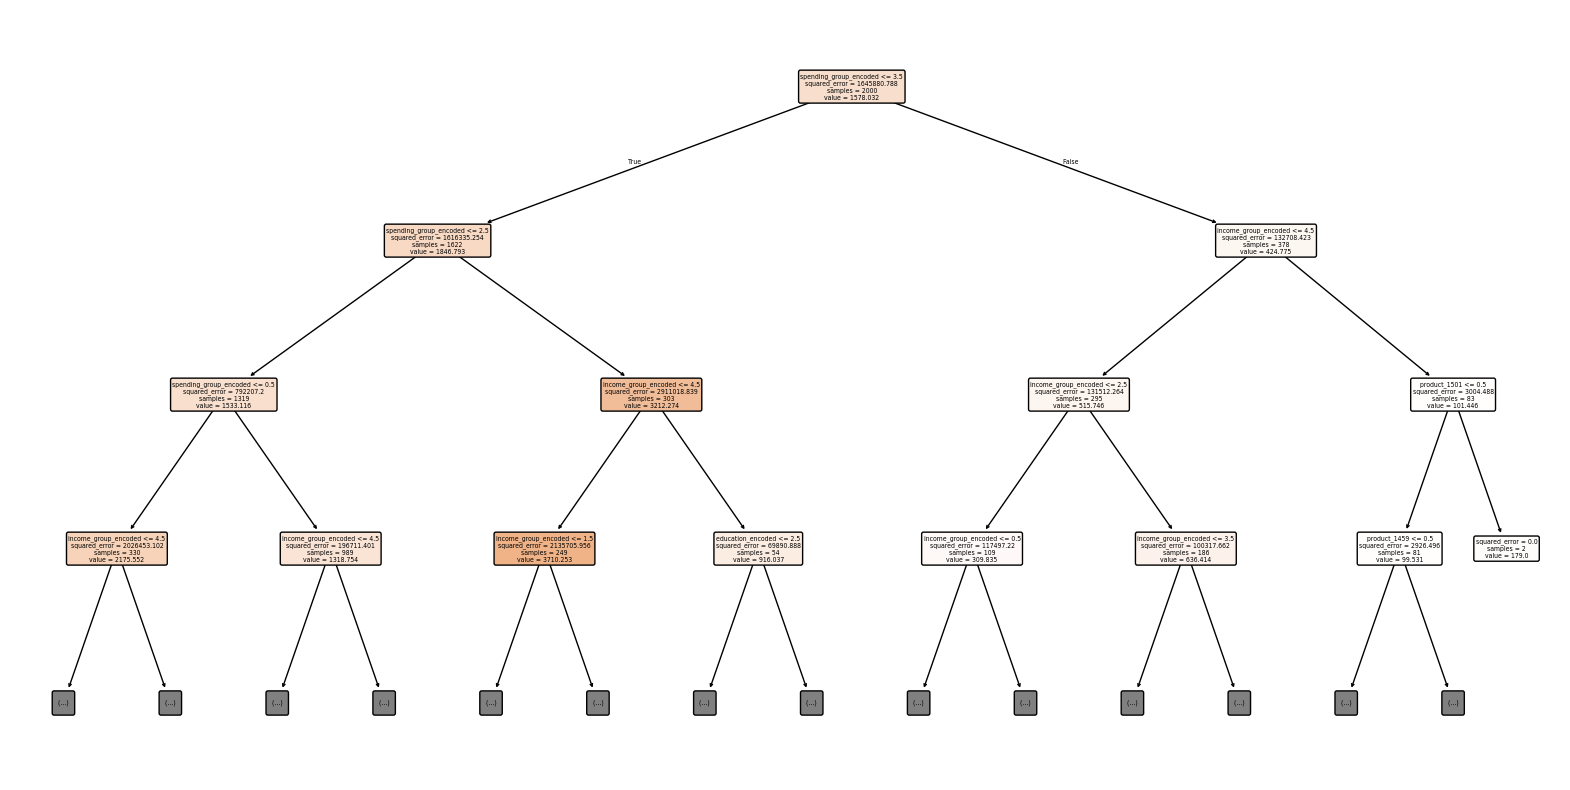

In [48]:
# Visualise the tree
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))

plot_tree(
    model,
    feature_names=X.columns,
    filled=True,
    rounded=True,
    max_depth=3  # keep small for readability
)

plt.show()

 ✔R² Score = 0.882 - model explains 88.2% of the variation in loyalty_points
✔ RMSE = 440.45- predictions are off by ~440 loyalty points.

✔ feature engineering clearly helped and model is highly effective at predicting customer loyalty value.

✔Feature Importance
Top drivers of loyalty points
 spending_group_encoded = 0.515
 income_group_encoded = 0.483

✔Together they explain ~99% of the model’s decision power.

✔Education is almost irrelevant (0.0017)

Loyalty is driven by:
🎮 Engagement (spending behaviour) — strongest
💰 Income level — nearly equal
👤 Demographics — weak
📦 Product choice — negligible


# Clustering

In [53]:
df4 = df1.copy()

In [54]:
df4.head(2)

,gender,age,income,spending_score,loyalty_points,education,product,education_encoded
0,Male,18,12.3,39,210,graduate,453,2.0
1,Male,23,12.3,81,524,graduate,466,2.0


In [55]:
df4= df4.drop(columns=['gender','age','loyalty_points','education','product','education_encoded'])
df4.head(2)

,income,spending_score
0,12.3,39
1,12.3,81


<function matplotlib.pyplot.show(close=None, block=None)>

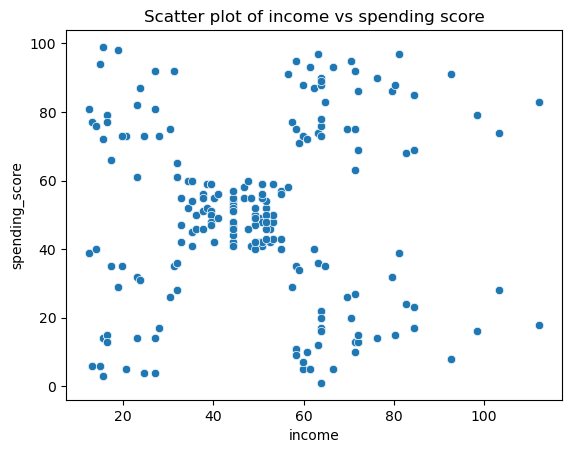

In [56]:
# scatter plot income vs spending score
sns.scatterplot(x='income',
                y='spending_score',
                data=df4)
plt.title('Scatter plot of income vs spending score')
plt.show

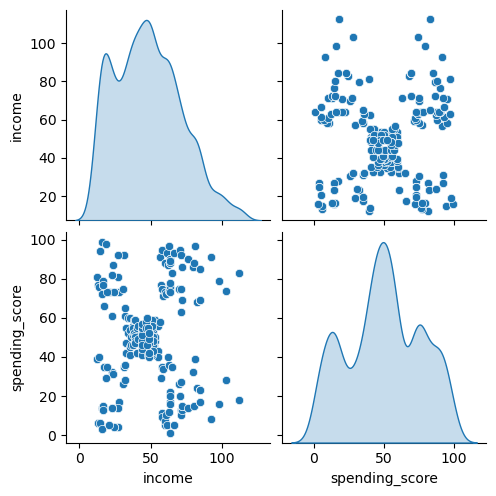

In [57]:
#  pairplot of income vs spending score
x = df4[['income', 'spending_score']]

sns.pairplot(df4,
             vars=x,
             diag_kind='kde')

Text(0, 0.5, 'SS distance')

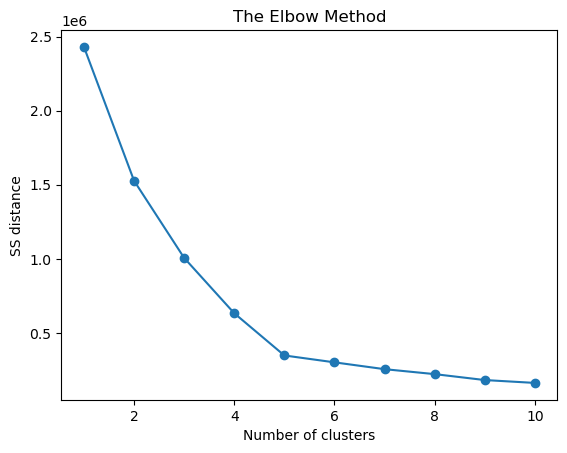

In [58]:
# determine the number of clusters: Elbow method.
from sklearn.cluster import KMeans 

# Elbow chart for# decideing on the number of optimal clusters.
ss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i,
                    init='k-means++',
                    max_iter=300,
                    n_init=10,
                    random_state=0)
    kmeans.fit(x)
    ss.append(kmeans.inertia_)

# Plot the elbow method.
plt.plot(range(1, 11),
         ss,
         marker='o')

# Insert labels and title.
plt.title("The Elbow Method")
plt.xlabel("Number of clusters")
plt.ylabel("SS distance")

<function matplotlib.pyplot.show(close=None, block=None)>

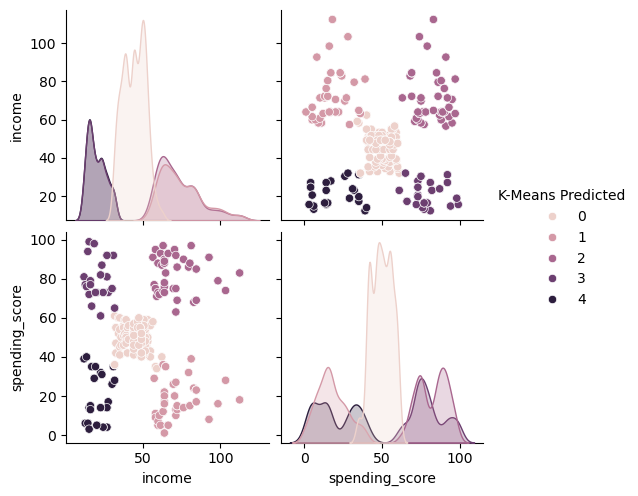

In [60]:
# Use 5 clusters
kmeans = KMeans(n_clusters = 5, 
                max_iter = 15000,
                init='k-means++',
                random_state=0).fit(x)

clusters = kmeans.labels_

x['K-Means Predicted'] = clusters

# Plot the predicted.
sns.pairplot(x,
             hue='K-Means Predicted',
             diag_kind= 'kde')
plt.show

In [61]:
x['K-Means Predicted'].value_counts()

K-Means Predicted
0    774
2    356
1    330
4    271
3    269
Name: count, dtype: int64

<function matplotlib.pyplot.show(close=None, block=None)>

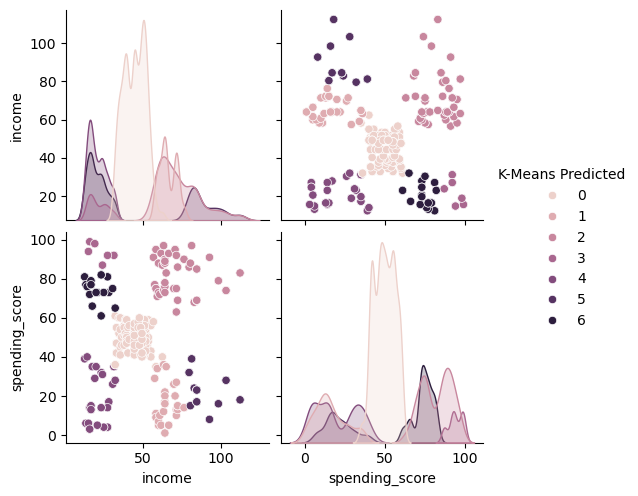

In [62]:
# Use 7 clusters
kmeans = KMeans(n_clusters = 7, 
                max_iter = 15000,
                init='k-means++',
                random_state=0).fit(x)

clusters = kmeans.labels_

x['K-Means Predicted'] = clusters

# Plot the predicted.
sns.pairplot(x,
             hue='K-Means Predicted',
             diag_kind= 'kde')
plt.show

In [63]:
x['K-Means Predicted'].value_counts()

K-Means Predicted
0    767
2    356
4    271
1    214
6    196
5    123
3     73
Name: count, dtype: int64

k = 5 (simpler segmentation) whereas k = 7 (more detailed segmentation). k=7 identify more granular behaviour groups, identifies niche segments (e.g. 73 users cluster) and better for targeted marketing.

In [64]:
# Visualising the clusters.
# View the K-Means predicted.
print(x.head())

   income  spending_score  K-Means Predicted
0   12.30              39                  4
1   12.30              81                  6
2   13.12               6                  4
3   13.12              77                  6
4   13.94              40                  4


✔ Even though income is almost the same (12–13 range), customers are split into different clusters based on spending_score.
✔ cluster 4  with spending_score 6, 39, 40 and cluster 6 with spendinf_score 77,81  higher pending_scaore.   

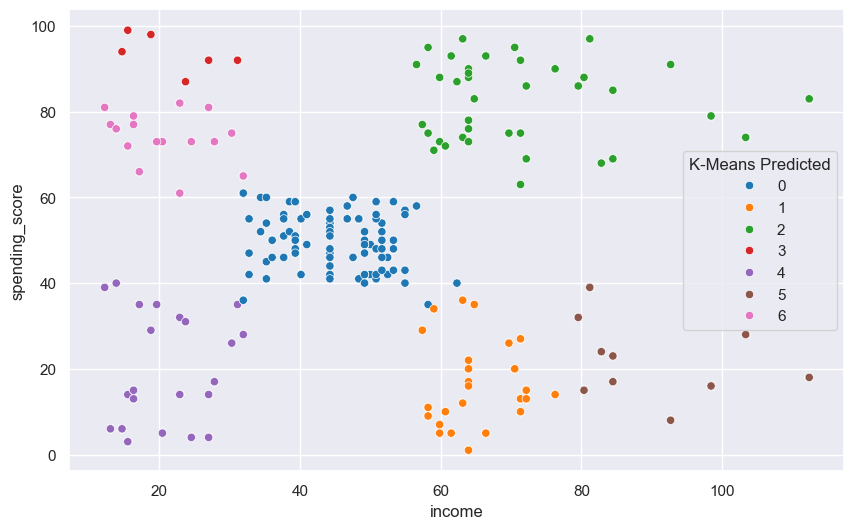

In [65]:
# visualise clusters
sns.set(rc={'figure.figsize': (10, 6)})

sns.scatterplot(
    x='income',
    y='spending_score',
    data=x,
    hue='K-Means Predicted',
    palette='tab10'   
)

plt.show()

In [66]:
# identifying the customers in clusters
# attach cluster labels to data
df4['cluster'] = kmeans.labels_

In [67]:
# understand each cluster (profiling)
df4.groupby('cluster')[['income', 'spending_score']].mean()

,income,spending_score
cluster,,
0,44.285346,49.671447
1,65.787757,15.808411
2,73.240281,82.008427
3,20.960548,93.958904
4,20.424354,19.763838
5,89.666667,21.178862
6,20.127653,74.000000


In [75]:
# add meaningful labels to clusters
def label_cluster(row):
    if row['income'] > 70 and row['spending_score'] > 70:
        return "VIP Customers"
    elif row['income'] > 70 and row['spending_score'] < 40:
        return "Wealthy but Low Engagement"
    elif row['income'] < 30 and row['spending_score'] > 70:
        return "Impulsive Low Income Spenders"
    elif row['income'] < 30 and row['spending_score'] < 30:
        return "Low Value Customers"
    else:
        return "Mid Segment Customers"

df4['segment'] = df4.apply(label_cluster, axis=1)       

In [76]:
df4

,income,spending_score,cluster,segment
0,12.30,39,4,Mid Segment Customers
1,12.30,81,6,Impulsive Low Income Spenders
2,13.12,6,4,Low Value Customers
3,13.12,77,6,Impulsive Low Income Spenders
4,13.94,40,4,Mid Segment Customers
...,...,...,...,...
1995,84.46,69,2,Mid Segment Customers
1996,92.66,8,5,Wealthy but Low Engagement
1997,92.66,91,2,VIP Customers
1998,98.40,16,5,Wealthy but Low Engagement


In [77]:
df4['segment'].unique()

array(['Mid Segment Customers', 'Impulsive Low Income Spenders',
       'Low Value Customers', 'Wealthy but Low Engagement',
       'VIP Customers'], dtype=object)

In [78]:
# number of customers in segments
df4['segment'].value_counts()

segment
Mid Segment Customers            1281
Impulsive Low Income Spenders     216
Wealthy but Low Engagement        193
Low Value Customers               167
VIP Customers                     143
Name: count, dtype: int64

## Clustering with more variables added

In [79]:
# deciding on variables for clustering
X = df1[['age', 'income', 'spending_score', 'loyalty_points']]

In [80]:
# scaling
from sklearn.preprocessing import StandardScaler
#from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
X1 = df1[['age', 'income', 'spending_score']]

scaler = StandardScaler()
X1_scaled = scaler.fit_transform(X1)

kmeans1 = KMeans(n_clusters=4, random_state=42, n_init=10)
labels1 = kmeans1.fit_predict(X1_scaled)

score1 = silhouette_score(X1_scaled, labels1)
print("Silhouette Score (without loyalty_points):", score1)

Silhouette Score (without loyalty_points): 0.3756879363380646


In [81]:
X2 = df1[['age', 'income', 'spending_score', 'loyalty_points']]

X2_scaled = scaler.fit_transform(X2)

kmeans2 = KMeans(n_clusters=4, random_state=42, n_init=10)
labels2 = kmeans2.fit_predict(X2_scaled)

score2 = silhouette_score(X2_scaled, labels2)
print("Silhouette Score (with loyalty_points):", score2)

Silhouette Score (with loyalty_points): 0.38547847092842696


Optimal clusters were selected using the elbow method and silhouette score.

The improvement is mminimal, suggesting that the core structure of the clusters is captured by age, income and spending_score.

In [82]:
# scaling

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Features
X = df1[['age', 'income', 'spending_score']]

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# KMeans
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df1['cluster'] = kmeans.fit_predict(X_scaled)

In [84]:
# K-Means prediction
df1['cluster'] =kmeans.fit_predict(X_scaled)

In [85]:
df1

,gender,age,income,spending_score,loyalty_points,education,product,education_encoded,cluster
0,Male,18,12.30,39,210,graduate,453,2.0,0
1,Male,23,12.30,81,524,graduate,466,2.0,0
2,Female,22,13.12,6,40,graduate,254,2.0,0
3,Female,25,13.12,77,562,graduate,263,2.0,0
4,Female,33,13.94,40,366,graduate,291,2.0,0
...,...,...,...,...,...,...,...,...,...
1995,Female,37,84.46,69,4031,PhD,977,4.0,2
1996,Female,43,92.66,8,539,PhD,979,4.0,1
1997,Male,34,92.66,91,5614,graduate,1012,2.0,2
1998,Male,34,98.40,16,1048,PhD,1031,4.0,1


In [86]:
df1.groupby('cluster')[['age', 'income', 'spending_score']].mean()

,age,income,spending_score
cluster,,,
0,29.120617,32.329621,57.112202
1,39.103245,74.182183,18.861357
2,35.448753,72.961828,81.537396
3,54.810903,36.831550,39.948893


In [87]:
# add meaningful labels to clusters
def label_segment(row):
    if row['income'] > 60 and row['spending_score'] > 60:
        return "VIP Customers"
    elif row['income'] > 60 and row['spending_score'] < 40:
        return "Wealthy but Low Engagement"
    elif row['income'] < 30 and row['spending_score'] > 60:
        return "Impulsive Low Income Spenders"
    elif row['income'] < 30 and row['spending_score'] < 30:
        return "Low Value Customers"
    else:
        return "Mid Segment Customers"

df1['segment'] = df1.apply(label_segment, axis=1)

In [88]:
df1['segment'].value_counts()

segment
Mid Segment Customers            996
VIP Customers                    300
Wealthy but Low Engagement       295
Impulsive Low Income Spenders    242
Low Value Customers              167
Name: count, dtype: int64

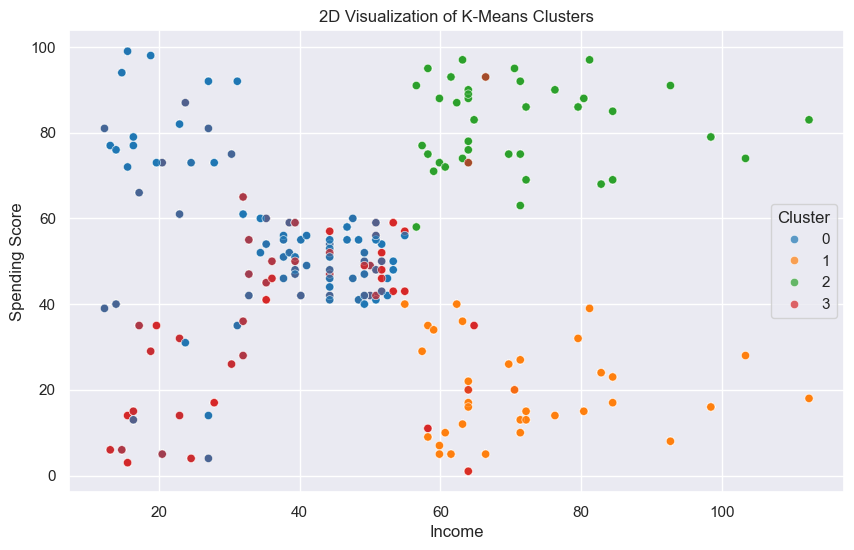

In [91]:
# visualising the model
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='income',
    y='spending_score',
    data=df1,
    hue='cluster',
    palette='tab10',
    alpha=0.7
)

plt.title('2D Visualization of K-Means Clusters')
plt.xlabel('Income')
plt.ylabel('Spending Score')
plt.legend(title='Cluster')

plt.show()

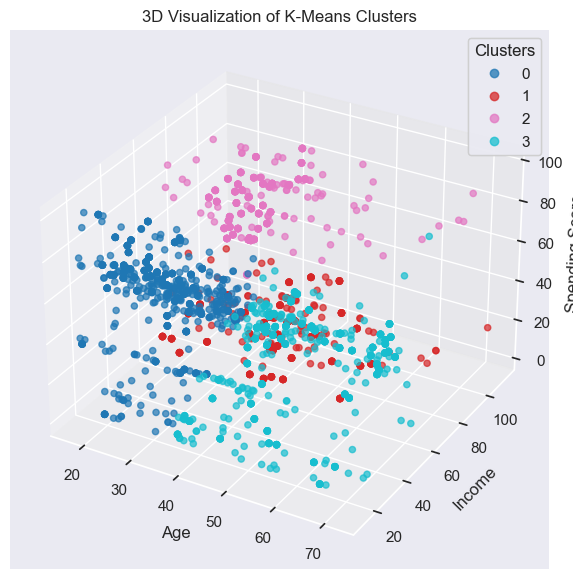

In [90]:
# 3D model
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot
scatter = ax.scatter(
    df1['age'],
    df1['income'],
    df1['spending_score'],
    c=df1['cluster'],
    cmap='tab10',
    alpha=0.7
)

# Labels
ax.set_xlabel('Age')
ax.set_ylabel('Income')
ax.set_zlabel('Spending Score')
ax.set_title('3D Visualization of K-Means Clusters')

# Legend
legend1 = ax.legend(*scatter.legend_elements(), title="Clusters")
ax.add_artist(legend1)

plt.show()

✔ When reducing the number of clusters from 7 to 5 or 4, it’s important not to oversimplify the boundaries between segments. 
✔ Customers who lie near the edges of clusters may be incorrectly reassigned, leading to potential misclassification and loss of meaningful distinctions.

In [94]:
# Find distance to cluster centers
distances = kmeans.transform(X_scaled)

# distance to assigned cluster
df1['distance_to_own_cluster'] = distances.min(axis=1)

In [96]:
# Identify how close they are to other clusters
import numpy as np

sorted_distances = np.sort(distances, axis=1)

# gap between closest and second closest cluster
df1['margin'] = sorted_distances[:, 1] - sorted_distances[:, 0]

In [98]:
# Flag marginal customers
threshold = df1['margin'].quantile(0.2)  # bottom 20% as "uncertain"
df1['is_borderline'] = df1['margin'] < threshold

In [99]:
# boarderline cuatomers
df1[df1['is_borderline'] == True]

,gender,age,income,spending_score,loyalty_points,education,product,education_encoded,cluster,segment,distance_to_own_cluster,margin,is_borderline
6,Female,37,14.76,6,61,diploma,979,1.0,3,Low Value Customers,2.080306,0.099888,True
14,Male,39,16.40,13,150,graduate,1506,2.0,3,Low Value Customers,1.790456,0.175235,True
16,Female,37,17.22,35,417,graduate,486,2.0,0,Mid Segment Customers,1.217680,0.356608,True
20,Male,37,19.68,35,476,postgraduate,1212,3.0,0,Mid Segment Customers,1.164033,0.355561,True
26,Female,43,22.96,32,534,graduate,624,2.0,3,Mid Segment Customers,1.100197,0.361647,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1970,Male,38,16.40,15,172,postgraduate,4065,3.0,3,Low Value Customers,1.797326,0.075823,True
1972,Male,38,16.40,13,149,graduate,453,2.0,3,Low Value Customers,1.839263,0.100342,True
1980,Female,39,20.50,5,72,graduate,1031,2.0,3,Low Value Customers,1.910832,0.275958,True
1989,Female,38,16.40,15,172,graduate,1031,2.0,3,Low Value Customers,1.797326,0.075823,True


In [101]:
# cluster distribution of borderline customers
df1[df1['is_borderline']]['cluster'].value_counts()

cluster
3    157
0    150
1     71
2     22
Name: count, dtype: int64

In [102]:
# identify these customers
df1.loc[df1['is_borderline'], ['cluster', 'margin']]

,cluster,margin
6,3,0.099888
14,3,0.175235
16,0,0.356608
20,0,0.355561
26,3,0.361647
...,...,...
1970,3,0.075823
1972,3,0.100342
1980,3,0.275958
1989,3,0.075823


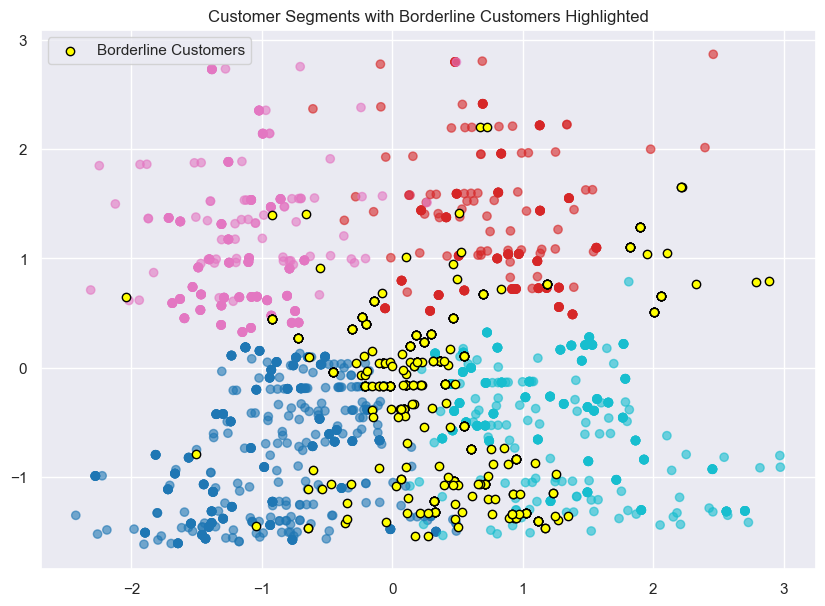

In [103]:
# visualise these borderline customers
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_scaled)

plt.figure(figsize=(10,7))

# normal customers
plt.scatter(X_2d[~df1['is_borderline'], 0],
            X_2d[~df1['is_borderline'], 1],
            c=df1.loc[~df1['is_borderline'], 'cluster'],
            cmap='tab10',
            alpha=0.6)

# borderline customers 
plt.scatter(X_2d[df1['is_borderline'], 0],
            X_2d[df1['is_borderline'], 1],
            c='yellow',
            edgecolor='black',
            label='Borderline Customers')

plt.title("Customer Segments with Borderline Customers Highlighted")
plt.legend()
plt.show()

### These 400 customers are borderline cases between clusters, meaning their behavior places them near segment boundaries. As a result, they are not stably assigned to a single segment and should be monitored, as they may transition between clusters over time.